<a href="https://colab.research.google.com/github/SuMyatMon17/AI_Solution_Development_Project/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Environment Setup and load data

This notebook performs exploratory data analysis (EDA) on the gas monitoring dataset, focusing on data quality, distribution, and feature relationships to guide preprocessing and model development.

In [ ]:
#import all the required libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Download the SQLite database file from a GitHub repository
!wget https://raw.githubusercontent.com/SuMyatMon17/AI_Solution_Development_Project/main/data/gas_monitoring.db -O gas_monitoring.db

import sqlite3, pandas as pd

db_path = "gas_monitoring.db"
conn = sqlite3.connect(db_path)
df_raw = pd.read_sql("SELECT * FROM gas_monitoring", conn)
conn.close()

df_raw.head(20)


--2026-06-11 06:45:44--  https://raw.githubusercontent.com/SuMyatMon17/AI_Solution_Development_Project/main/data/gas_monitoring.db
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1732608 (1.7M) [application/octet-stream]
Saving to: ‘gas_monitoring.db’

gas_monitoring.db   100%[===================>]   1.65M  9.30MB/s    in 0.2s    

2026-06-11 06:45:45 (9.30 MB/s) - ‘gas_monitoring.db’ saved [1732608/1732608]



,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity
5,afternoon,19.82,47.71,79.489742,616.349705,557.929178,779.316801,738.876591,664.886531,1.0,7241,Ventilation_Only,very_bright,Low Activity
6,night,20.04,48.42,118.293529,582.624643,474.777417,736.890795,694.939447,628.884980,1.0,6431,heating_active,bright,Low Activity
7,night,19.29,52.67,136.292680,574.121555,474.924866,721.380249,680.511012,622.275067,1.0,7963,maintenance_mode,bright,Moderate Activity
8,afternoon,292.59,47.92,74.100322,624.577270,564.745091,798.290403,753.467986,674.278245,0.0,7241,maintenance_mode,very_bright,Low Activity
9,night,19.81,-48.34,8.964022,595.833260,464.828130,737.958044,687.714744,622.836602,NaN,2105,ventilation_only,None,Low Activity


# Data Overview

In [ ]:
# Display a concise summary of the DataFrame, including data types and non-null values
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

Categorical Data Standardization

In [ ]:
# Standardize 'Time of Day' column
df_raw['Time of Day'] = df_raw['Time of Day'].str.lower().str.strip()

# Standardize 'HVAC Operation Mode' column
df_raw['HVAC Operation Mode'] = df_raw['HVAC Operation Mode'].str.lower().str.strip()

# Standardize 'Ambient Light Level' column
df_raw['Ambient Light Level'] = df_raw['Ambient Light Level'].str.lower().str.strip()

# Standardize 'Activity Level' column, replacing underscores and correcting specific labels
df_raw['Activity Level'] = df_raw['Activity Level'].str.lower().str.strip().str.replace('_', ' ', regex=False).replace({'lowactivity': 'low activity', 'moderateactivity': 'moderate activity'})

Categorical values were standardized by converting text to lowercase, removing extra spaces, and fixing inconsistent labels to improve consistency for EDA and model training.

Rearranging Rows by Session ID

In [ ]:
# Sort the DataFrame by 'Session ID' in ascending order
df_raw = df_raw.sort_values(
    by="Session ID",
    ascending=True
)

# Display the first 20 rows of the sorted DataFrame
df_raw.head(20)

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
1885,afternoon,21.880000,44.23,114.993800,592.042931,434.778993,735.249639,702.156806,615.620900,NaN,1374,cooling_active,bright,high activity
1828,morning,18.020000,46.63,82.419737,610.153862,498.499105,764.572379,725.089410,678.069234,0.0,1374,off,moderate,low activity
9873,evening,20.050000,51.00,118.137116,586.135449,446.988854,NaN,632.391887,554.373709,2.0,1374,cooling_active,None,moderate activity
9875,night,18.540000,NaN,120.554285,591.421466,480.238613,747.631334,709.608994,646.301688,1.0,1374,off,very_bright,moderate activity
9823,evening,22.630000,46.11,21.376581,583.769443,463.879191,735.573011,681.830062,628.554769,1.0,1374,heating_active,bright,moderate activity
2620,afternoon,17.450000,NaN,87.405254,612.108210,556.839594,NaN,741.225193,668.747077,0.0,1374,heating_active,very_bright,high activity
2645,afternoon,21.590000,44.75,109.822895,591.371294,432.757429,737.438899,694.116930,638.465106,1.0,1374,eco_mode,very_bright,moderate activity
2623,afternoon,17.730000,48.82,97.217427,602.672854,554.198154,769.269874,480.321243,687.863025,0.0,1374,cooling_active,moderate,moderate activity
2593,morning,28.483264,46.60,67.377484,615.405777,580.618470,783.753133,760.004229,711.328306,0.0,1374,eco_mode,very_dim,moderate activity
2594,morning,16.000000,47.07,72.193842,615.731314,611.643679,788.492289,768.972574,717.889514,0.0,1374,off,bright,moderate activity


# Missing Data Exploration

In [ ]:
# Check for non-null values in the DataFrame
df_raw.notnull()

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
1885,True,True,True,True,True,True,True,True,True,False,True,True,True,True
1828,True,True,True,True,True,True,True,True,True,True,True,True,True,True
9873,True,True,True,True,True,True,False,True,True,True,True,True,False,True
9875,True,True,False,True,True,True,True,True,True,True,True,True,True,True
9823,True,True,True,True,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2422,True,True,False,True,True,True,True,True,True,True,True,True,True,True
404,True,True,True,True,True,True,True,True,True,False,True,True,True,True
31,True,True,True,True,True,True,True,True,True,True,True,True,True,True
9980,True,True,True,True,True,True,True,True,True,False,True,True,True,True


In [ ]:
# Calculate the sum of null values for each column
df_raw.isnull().sum()

,0
Time of Day,0
Temperature,0
Humidity,1928
CO2_InfraredSensor,0
CO2_ElectroChemicalSensor,0
MetalOxideSensor_Unit1,0
MetalOxideSensor_Unit2,1410
MetalOxideSensor_Unit3,0
MetalOxideSensor_Unit4,0
CO_GasSensor,834


Key Observation: The missing value analysis shows that several features contain missing data. Humidity has the highest number of missing values (1,928), followed by MetalOxideSensor_Unit2 (1,410), Ambient Light Level (1,054), and CO_GasSensor (834). The remaining features do not contain any missing values. Since these variables are important for understanding environmental conditions and predicting activity levels, appropriate missing value handling will be performed during preprocessing to ensure data quality and improve model performance.

# Duplicate Data Exploration

In [ ]:
# Identify all duplicate rows in the DataFrame
full_duplicates = df_raw.duplicated()

# Print the total number of full row duplicates found
print(
    "Full row duplicates:",
    full_duplicates.sum()
)

# Display the first 20 rows that are identified as full duplicates
df_raw[full_duplicates].head(20)

Full row duplicates: 265


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
2353,morning,18.07,52.47,116.984140,596.032950,485.932116,762.102352,734.793427,656.202911,1.0,1374,heating_active,dim,low activity
6550,afternoon,21.59,44.75,109.822895,591.371294,432.757429,737.438899,694.116930,638.465106,1.0,1374,eco_mode,very_bright,moderate activity
1137,morning,17.99,52.41,122.561974,592.362155,471.020247,743.116299,688.897073,626.213930,1.0,1374,cooling_active,bright,moderate activity
8809,morning,17.57,53.11,122.855690,592.614287,500.585812,751.279196,701.155042,649.035866,1.0,1374,eco_mode,very_dim,low activity
2531,morning,17.90,52.62,114.943077,592.598601,491.368258,754.609372,728.144610,653.696325,1.0,1374,ventilation_only,very_bright,low activity
8200,morning,16.80,49.98,102.504902,596.979672,512.225326,762.622265,706.939271,660.867415,1.0,1374,heating_active,very_bright,moderate activity
2624,afternoon,17.56,49.09,89.444437,606.028654,556.101782,766.360175,731.305826,677.078106,0.0,1374,cooling_active,bright,low activity
7305,night,18.88,51.67,123.873710,588.731538,482.444130,732.393147,672.252629,601.851890,1.0,1374,cooling_active,bright,high activity
2636,afternoon,19.92,47.81,115.489467,593.443170,433.043947,729.092451,683.163966,639.949618,0.0,1374,ventilation_only,bright,low activity
2611,afternoon,17.65,NaN,86.974478,607.000272,563.175713,776.174485,746.993438,687.678051,0.0,1374,off,very_bright,moderate activity


In [ ]:
# rows involved in exact duplicate groups
dup_mask = df_raw.duplicated(
    subset=list(df_raw.columns),
    keep=False
)

# Create a DataFrame of all exact duplicate rows
all_exact_duplicates = df_raw[dup_mask].copy()

# sort so identical rows appear next to each other
all_exact_duplicates = all_exact_duplicates.sort_values(
    by=list(df_raw.columns)
)

# Print the total number of rows involved in exact duplicate groups
print("Rows involved in exact duplicate groups:", len(all_exact_duplicates))

# Display the duplicate rows
all_exact_duplicates

Rows involved in exact duplicate groups: 525


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
9406,afternoon,16.23,48.80,70.882709,603.860514,555.459308,773.267088,741.565757,679.691277,0.0,6431,eco_mode,dim,low activity
4136,afternoon,16.23,48.80,70.882709,603.860514,555.459308,773.267088,741.565757,679.691277,0.0,6431,eco_mode,dim,low activity
4558,afternoon,16.31,NaN,68.491189,614.586116,584.049252,785.959876,752.976856,698.361532,0.0,5820,eco_mode,None,moderate activity
2899,afternoon,16.31,NaN,68.491189,614.586116,584.049252,785.959876,752.976856,698.361532,0.0,5820,eco_mode,None,moderate activity
3470,afternoon,16.56,45.82,63.558315,615.347358,632.891693,789.609160,768.964066,707.689461,0.0,3418,off,bright,moderate activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4006,night,22.46,53.89,128.841981,549.510544,466.706268,705.459465,661.439758,594.877674,1.0,3592,heating_active,very_bright,low activity
3952,night,22.82,52.13,143.995724,559.293344,339.394737,668.907365,603.058057,525.809288,2.0,3074,cooling_active,very_bright,low activity
4969,night,22.82,52.13,143.995724,559.293344,339.394737,668.907365,603.058057,525.809288,2.0,3074,cooling_active,very_bright,low activity
4134,night,23.19,48.92,121.393677,568.186457,386.093867,681.539270,637.299590,555.150185,3.0,7395,maintenance_mode,very_bright,low activity


Key Observation:

The initial exploration identified 525 rows involved in exact duplicate groups within the raw dataset. These duplicate records may represent either repeated environmental measurements under stable indoor conditions or duplicated entries introduced during data collection and storage.

Since this analysis was performed on the raw dataset, further preprocessing and investigation will be required before deciding whether the duplicate records should be retained or removed for model training.

# Outliers Exploration

In [ ]:
# Display descriptive statistics for numerical columns
df_raw.describe()

,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID
count,10000.000000,8072.000000,10000.000000,10000.000000,10000.000000,8590.000000,10000.000000,10000.000000,9166.000000,10000.000000
mean,42.243124,51.643609,109.864352,578.634082,470.932316,728.354408,680.488646,612.247715,1.288239,5427.921400
std,73.974956,21.333894,33.793851,22.573537,51.459025,29.140123,55.953530,43.174354,0.779754,2590.836924
min,6.903485,-49.870000,-17.472184,408.599386,286.825662,611.168916,456.673900,412.791904,0.000000,1374.000000
25%,18.937500,47.660000,96.660377,559.353100,440.035413,709.660122,658.519775,585.511731,1.000000,3074.000000
50%,20.510000,51.390000,112.807103,579.361082,469.146955,726.748925,679.908353,609.526245,1.000000,5214.000000
75%,23.172500,53.840000,124.540226,595.569759,494.770045,744.879789,703.522845,636.012105,2.000000,7395.000000
max,307.070000,198.900000,237.873938,637.895790,632.891693,807.732943,906.213097,736.112361,4.000000,9658.000000


In [ ]:
# Selects all numerical columns from the DataFrame
numerical_cols = df_raw.select_dtypes(include=np.number).columns

# Initialize a dictionary to store outlier counts for each column
outliers_count = {}
# Iterate through each numerical column
for col in numerical_cols:
    # Calculate the first quartile (Q1)
    Q1 = df_raw[col].quantile(0.25)
    # Calculate the third quartile (Q3)
    Q3 = df_raw[col].quantile(0.75)
    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1
    # Define the lower bound for outlier detection
    lower_bound = Q1 - 1.5 * IQR
    # Define the upper bound for outlier detection
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers for the current column using the IQR method
    col_outliers = df_raw[(df_raw[col] < lower_bound) | (df_raw[col] > upper_bound)]
    # Store the count of outliers for the current column
    outliers_count[col] = len(col_outliers)

# Print the total number of outliers found for each numerical column
print("Number of outliers per numerical column (using IQR method):\n", outliers_count)

Number of outliers per numerical column (using IQR method):
 {'Temperature': 994, 'Humidity': 414, 'CO2_InfraredSensor': 805, 'CO2_ElectroChemicalSensor': 5, 'MetalOxideSensor_Unit1': 609, 'MetalOxideSensor_Unit2': 160, 'MetalOxideSensor_Unit3': 820, 'MetalOxideSensor_Unit4': 293, 'CO_GasSensor': 75, 'Session ID': 0}


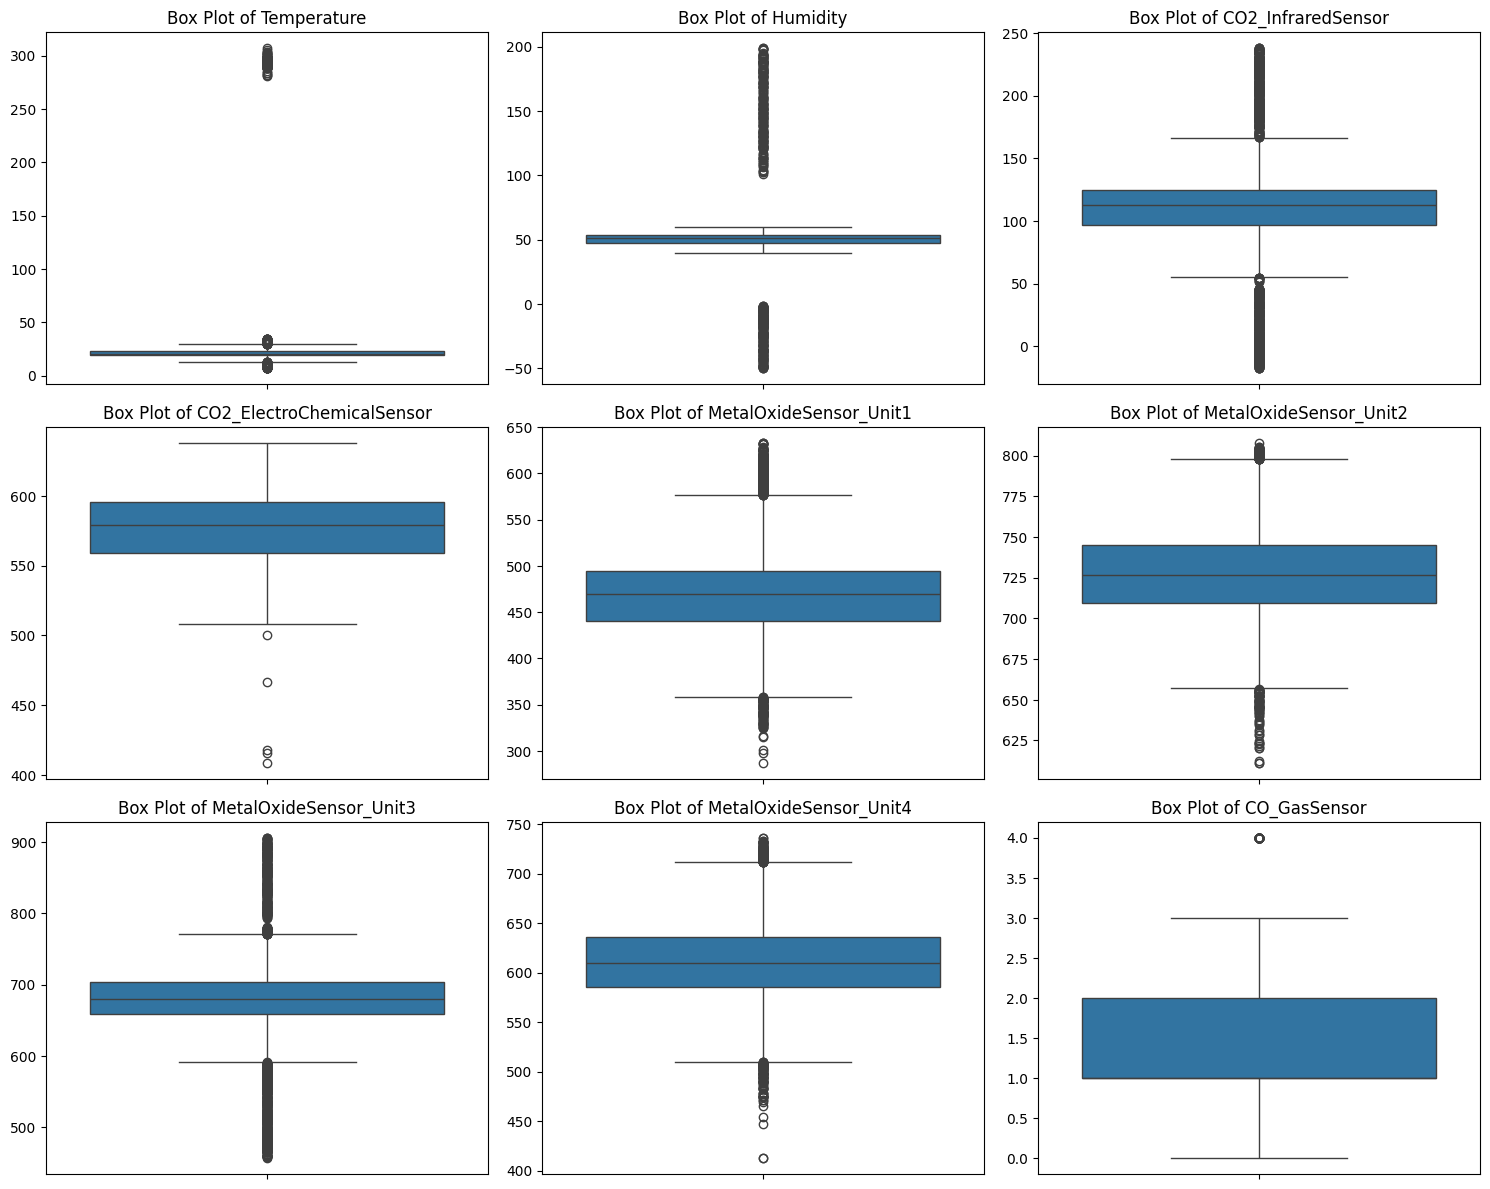

In [ ]:
# Identify numerical columns that have outliers
numerical_cols_with_outliers = [col for col, count in outliers_count.items() if count > 0]

# Check if any outliers were found
if not numerical_cols_with_outliers:
    print("No numerical columns with outliers were identified based on the previous calculation.")
else:
    num_plots = len(numerical_cols_with_outliers)
    num_cols = 3 # Number of columns for subplots
    num_rows = (num_plots + num_cols - 1) // num_cols # Calculate number of rows needed

    # Create a figure and a set of subplots
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten() # Flatten the array of axes for easy iteration

    # Iterate through each column with outliers and create a box plot
    for i, col in enumerate(numerical_cols_with_outliers):
        sns.boxplot(y=df_raw[col], ax=axes[i])
        axes[i].set_title(f'Box Plot of {col}')
        axes[i].set_ylabel('') # Remove y-label to avoid clutter, title is sufficient

    # Hide any unused subplots to clean up the display
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Adjust layout to prevent labels from overlapping
    plt.tight_layout()
    # Display the plots
    plt.show()

Key Observation: The box plots show that several numerical features contain outliers, particularly Temperature, Humidity, CO2_InfraredSensor, CO2_ElectroChemicalSensor, and the Metal Oxide sensors. Some of these values are located far outside the normal data range, which may represent unusual environmental conditions, sensor noise, or contaminated records. The presence of these outliers could affect model performance by influencing feature distributions and prediction results. Therefore, outlier treatment was included in the preprocessing stage using the IQR method to reduce the impact of extreme values while retaining the majority of the data.

# Categorical Data Overview

In [ ]:
# Selects all categorical columns (object type) from the DataFrame
categorical_cols = df_raw.select_dtypes(include='object').columns

# Check if there are any categorical columns
if not categorical_cols.empty:
    # Iterate through each categorical column
    for col in categorical_cols:
        # Print a header for the current column
        print(f"\n--- Categorical Column: {col} ---")
        # Display the value counts for the current column
        print(df_raw[col].value_counts())
        # Print the number of unique values in the current column
        print(f"Number of unique values: {df_raw[col].nunique()}")
else:
    # If no categorical columns are found, print a message
    print("No categorical columns found in the DataFrame.")


--- Categorical Column: Time of Day ---
Time of Day
afternoon    2635
evening      2476
morning      2460
night        2429
Name: count, dtype: int64
Number of unique values: 4

--- Categorical Column: HVAC Operation Mode ---
HVAC Operation Mode
cooling_active      1728
maintenance_mode    1703
eco_mode            1673
heating_active      1660
off                 1652
ventilation_only    1584
Name: count, dtype: int64
Number of unique values: 6

--- Categorical Column: Ambient Light Level ---
Ambient Light Level
very_bright    3387
bright         2697
moderate       1463
dim             864
very_dim        535
Name: count, dtype: int64
Number of unique values: 5

--- Categorical Column: Activity Level ---
Activity Level
low activity         5767
moderate activity    3138
high activity        1095
Name: count, dtype: int64
Number of unique values: 3


/tmp/ipykernel_1328/174042512.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


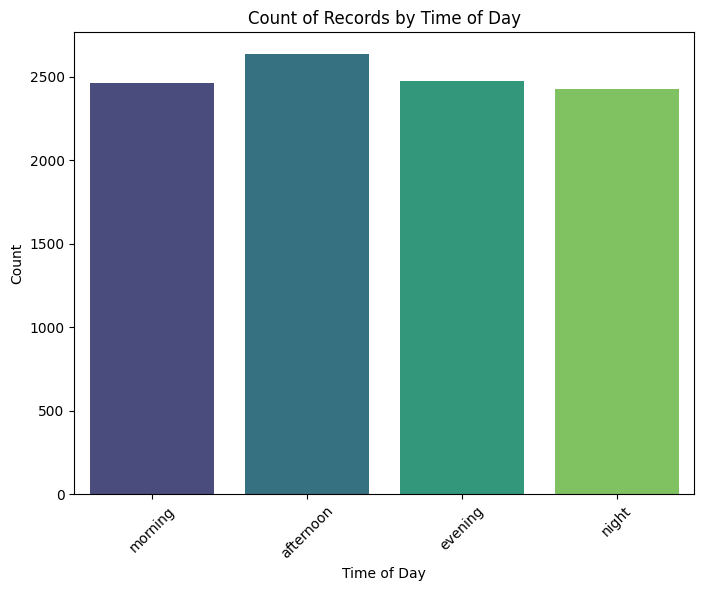

In [ ]:
# Bar plot for Time of Day counts
plt.figure(figsize=(8, 6))

time_order = [
    "morning",
    "afternoon",
    "evening",
    "night"
]

sns.countplot(
    x="Time of Day",
    data=df_raw,
    order=time_order,
    palette="viridis"
)

plt.title("Count of Records by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Key Observation:

These initial records are quite evenly distributed across different times of the day, with afternoon having slightly more records while morning, evening, and night have slightly lower but similar counts. This shows that the dataset contains data collected throughout the whole day and is not heavily focused on only one time period reducing the risk of severe time-based sampling bias during Activity Level prediction.

Since this analysis was conducted before handling missing values, duplicates, and outliers, the distribution may change slightly after preprocessing

/tmp/ipykernel_1328/1385222783.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="HVAC Operation Mode", data=df_raw, palette="inferno")


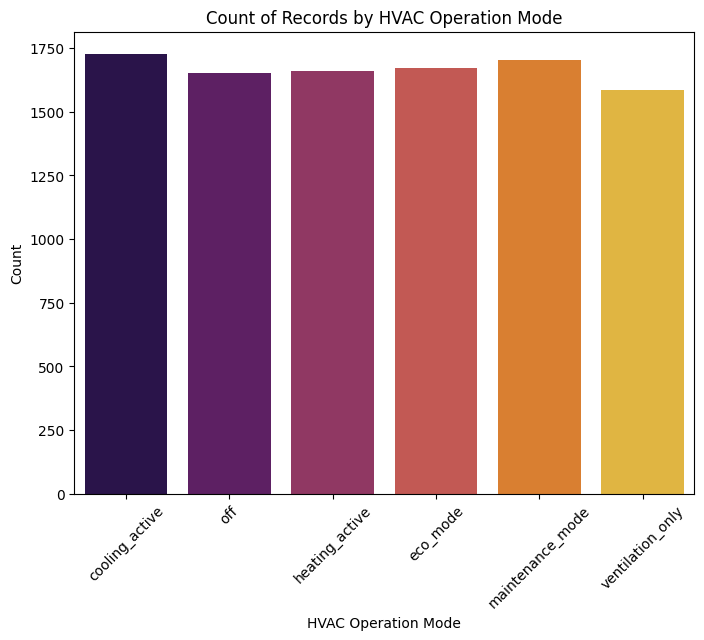

In [ ]:
# Bar plot for HVAC Operation Mode
plt.figure(figsize=(8, 6))
sns.countplot(x="HVAC Operation Mode", data=df_raw, palette="inferno")

plt.title("Count of Records by HVAC Operation Mode")
plt.xlabel("HVAC Operation Mode")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Key Observation:

The records are fairly distributed across the different HVAC operation modes with cooling_active and maintenance_mode having slightly higher counts while ventilation_only has the lowest. This suggests that the dataset includes a variety of indoor environmental operating conditions rather than focusing heavily on only one HVAC mode. This balanced distribution may help the model learn activity patterns under different indoor environmental conditions more effectively during training and prediction.

However, since this analysis was conducted before handling missing values, duplicates, and outliers, the distribution may change slightly after preprocessing

/tmp/ipykernel_1328/2245571215.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


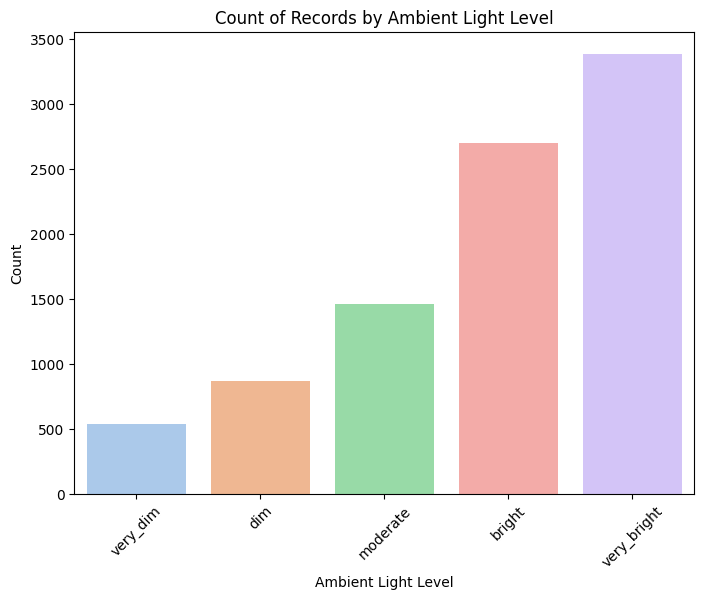

In [ ]:
# Bar plot for Ambient Light Level counts
plt.figure(figsize=(8, 6))

light_order = [
    "very_dim",
    "dim",
    "moderate",
    "bright",
    "very_bright"
]

sns.countplot(
    x="Ambient Light Level",
    data=df_raw,
    order=light_order,
    palette="pastel"
)

plt.title("Count of Records by Ambient Light Level")
plt.xlabel("Ambient Light Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Key Observation:

The initial distribution of records across ambient light levels appears uneven, with very_bright and bright having the highest number of records, while dim and very_dim contain fewer samples. This suggests that the raw dataset currently contains more observations collected under brighter lighting conditions compared to darker environments.  The imbalance may later affect model training, as the model could learn activity patterns more effectively under brighter conditions than dim lighting environments.

As this is still raw data before preprocessing, the distribution may change slightly after data cleaning.

/tmp/ipykernel_1328/3130267547.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


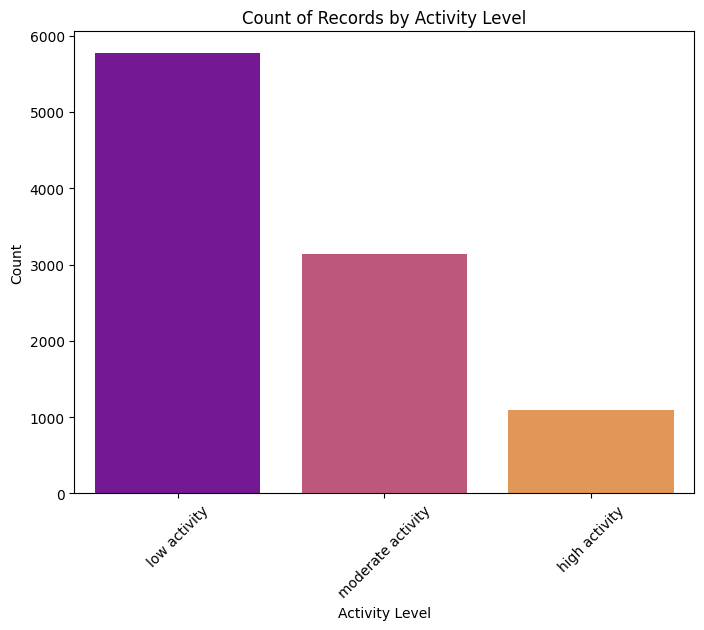

In [ ]:
# Bar plot for Activity Level
plt.figure(figsize=(8, 6))

activity_order = [
    "low activity",
    "moderate activity",
    "high activity"
]

sns.countplot(
    x="Activity Level",
    data=df_raw,
    order=activity_order,
    palette="plasma"
)

plt.title("Count of Records by Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Key Observation:

The initial distribution of records across Activity Levels appears imbalanced with low activity having the highest number of records, followed by moderate activity while high activity contains significantly fewer samples. This suggests that the raw dataset currently contains more observations for lower activity situations compared to higher activity conditions. The imbalance may later affect model training, as the model could become more biased toward predicting the dominant low activity category more frequently than minority classes.

These observations are based on the raw dataset and may change slightly after preprocessing.

After cleaning in .py, data correlation and visualisation

# Correlation Heat Map

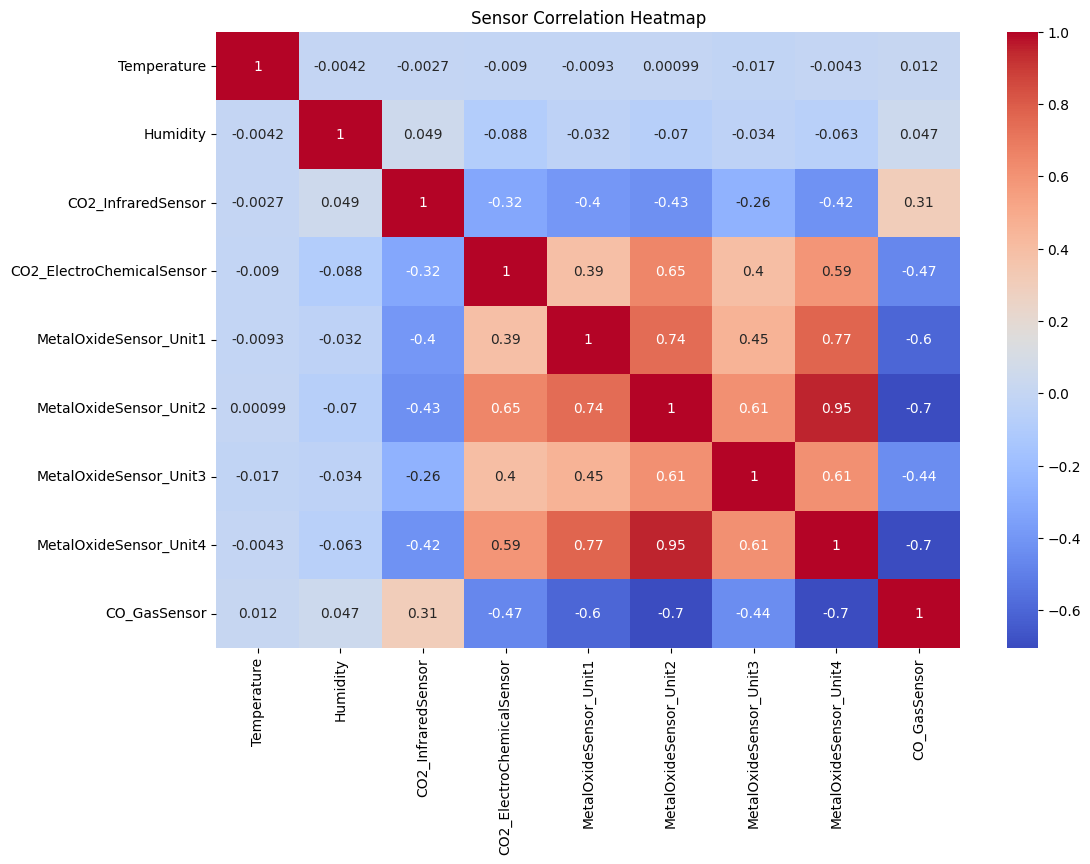

In [ ]:
# Select numerical columns and drop 'Session ID'
num_cols = df_raw.select_dtypes(
    include=np.number
).drop(
    columns=["Session ID"]
)

# Create a new figure for the heatmap
plt.figure(figsize=(12,8))

# Generate a heatmap of the correlation matrix
sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

# Set the title of the heatmap
plt.title(
    "Sensor Correlation Heatmap"
)

# Display the plot
plt.show()

Key Observation:

(A) Positive Linearity

Several Metal Oxide sensors exhibit strong positive linear relationships, meaning their readings tend to increase and decrease together. The strongest positive correlation is observed between MetalOxideSensor_Unit2 and MetalOxideSensor_Unit4 (r = 0.95), followed by Unit1 and Unit4 (r = 0.77) and Unit1 and Unit2 (r = 0.74). This indicates that these sensor pairs respond similarly to changes in environmental conditions.

(B) Negative Linearity

Strong negative linear relationships are observed between CO_GasSensor and MetalOxideSensor_Unit2 (r = -0.70) and CO_GasSensor and MetalOxideSensor_Unit4 (r = -0.70). This suggests that as Metal Oxide sensor readings increase, CO Gas sensor readings tend to decrease, indicating opposite sensor behaviour.

(C) Multicollinearity

The strong positive correlations among the Metal Oxide sensors, particularly Unit2 and Unit4 (r = 0.95), indicate the presence of multicollinearity. While positive linearity describes how two variables move together, multicollinearity refers to the modeling issue caused by highly correlated features providing overlapping or redundant information. To reduce this redundancy, PCA was applied to combine the Metal Oxide sensors into a single feature.

(D) Weak Linear Relationships

Temperature and Humidity show correlations close to zero with most sensor measurements. This suggests that these environmental variables have little or no linear relationship with the gas sensor readings and may contribute information independently of the gas sensors.

(E) Non-Linearity

The correlation heatmap cannot directly identify non-linear relationships because Pearson correlation only measures linear associations. Therefore, variables with weak correlations may still have meaningful non-linear relationships that are not visible in the heatmap which can be captured by models such as Decision Trees, Random Forests, and XGBoost.

However, since this analysis was conducted before handling missing values, duplicates, and outliers, the distribution may change slightly after preprocessing

# Pearson Correlation to check 4 metal oxide sensors and 2 CO2 sensors for feature engineering

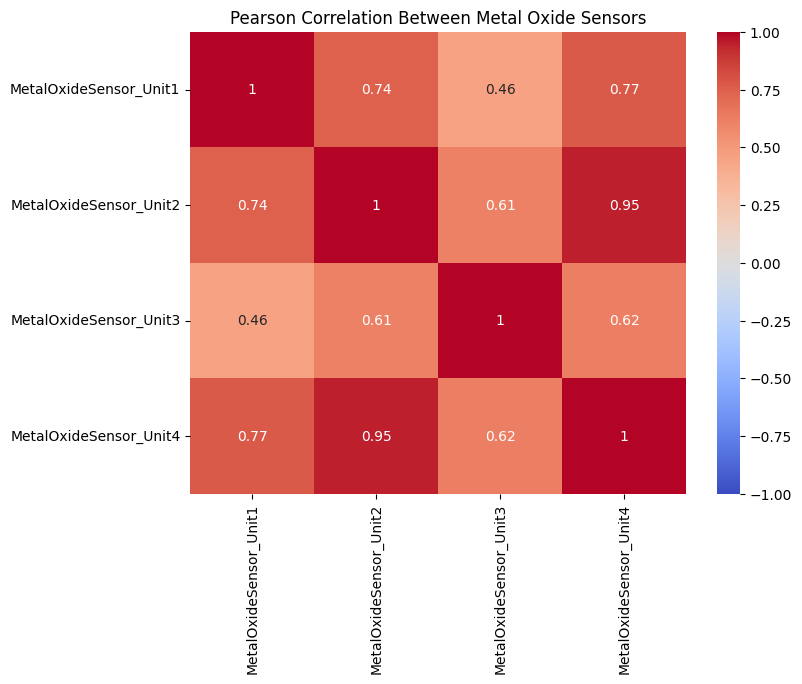

                        MetalOxideSensor_Unit1  MetalOxideSensor_Unit2  \
MetalOxideSensor_Unit1                1.000000                0.742308   
MetalOxideSensor_Unit2                0.742308                1.000000   
MetalOxideSensor_Unit3                0.459985                0.612475   
MetalOxideSensor_Unit4                0.770294                0.949585   

                        MetalOxideSensor_Unit3  MetalOxideSensor_Unit4  
MetalOxideSensor_Unit1                0.459985                0.770294  
MetalOxideSensor_Unit2                0.612475                0.949585  
MetalOxideSensor_Unit3                1.000000                0.617760  
MetalOxideSensor_Unit4                0.617760                1.000000  


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the list of metal oxide sensor columns
metal_cols = [
    "MetalOxideSensor_Unit1",
    "MetalOxideSensor_Unit2",
    "MetalOxideSensor_Unit3",
    "MetalOxideSensor_Unit4"
]

# Create a copy of the relevant columns from the raw DataFrame
metal_df = df_raw[metal_cols].copy()

# Drop rows with missing values
metal_df = metal_df.dropna()

# Calculate Pearson Correlation Matrix
correlation_df = metal_df.corr(method="pearson")

# Create a new figure for the heatmap visualization
plt.figure(figsize=(8, 6))

# Generate a heatmap to visualize the correlation matrix
sns.heatmap(
    correlation_df,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

# Set the title of the heatmap
plt.title("Pearson Correlation Between Metal Oxide Sensors")

# Display the plot
plt.show()

# Print the correlation matrix
print(correlation_df)

Key Observation: MetalOxideSensor_Unit2 and MetalOxideSensor_Unit4 exhibit the strongest positive correlation (r = 0.95), indicating a very strong positive linear relationship and suggesting that they may contain overlapping information. In contrast, MetalOxideSensor_Unit3 shows the weakest correlation with the other Metal Oxide sensors, particularly with Unit1 (r = 0.46), indicating a weaker linear relationship and potentially capturing more distinct information. The high correlations among several Metal Oxide sensors suggest the presence of multicollinearity. Based on this observation, PCA was applied during feature engineering to combine the Metal Oxide sensors into a single feature and reduce redundancy. Rows containing missing Metal Oxide sensor values were removed before calculating the Pearson correlation matrix.

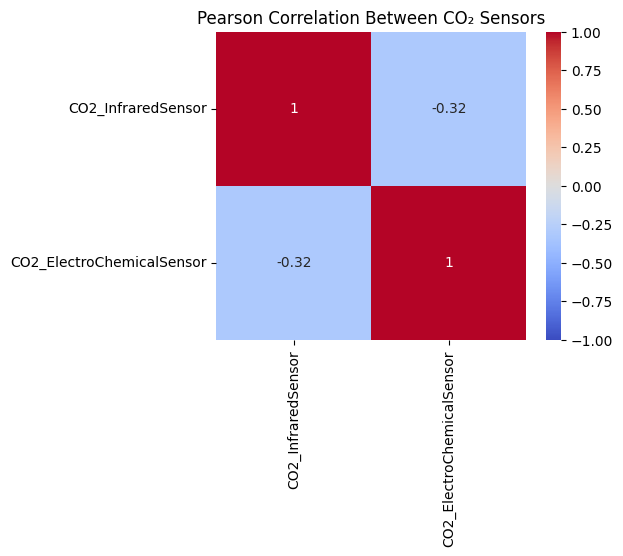

                           CO2_InfraredSensor  CO2_ElectroChemicalSensor
CO2_InfraredSensor                   1.000000                  -0.318149
CO2_ElectroChemicalSensor           -0.318149                   1.000000


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select the two CO₂ sensor columns
co2_cols = [
    "CO2_InfraredSensor",
    "CO2_ElectroChemicalSensor"
]

# Copy and clean data
co2_df = df_raw[co2_cols].dropna()

# Calculate Pearson Correlation
correlation_df = co2_df.corr(method="pearson")

# Plot heatmap
plt.figure(figsize=(5, 4))

sns.heatmap(
    correlation_df,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Pearson Correlation Between CO₂ Sensors")
plt.show()

# Print numeric results
print(correlation_df)

Key Observation: The CO₂ Infrared Sensor and CO₂ Electrochemical Sensor exhibit a moderate negative correlation (r = -0.32), indicating a weak-to-moderate negative linear relationship where higher readings from one sensor tend to be associated with lower readings from the other. This suggests that the two sensors may capture different aspects of CO₂ concentration due to their distinct sensing technologies or measurement sensitivities. As the correlation is relatively weak and well below the threshold for multicollinearity, the sensors are unlikely to provide redundant information. Instead, they may offer complementary information that can improve the robustness of activity prediction and environmental monitoring when used together in the model.